# Homework 2

## Your Name Here (or your names here if you are pair programming)

 - Student Name: Lily Nguyen
 - Student UT EID: lmn934


 - Partner Name: John "Jack" Mayberry
 - Partner UT EID: jmm23398

## Practicing Pandas


In [1]:
!pip3 install -qU pandas
!pip3 install -qU numpy

In [2]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

In [3]:
print("Numpy Version is: ", np.__version__)
print("Pandas Version is: ", pd.__version__)

Numpy Version is:  2.3.1
Pandas Version is:  2.3.0


# Social Network Dataset

In this assignment we work with a social network dataset. 

You have 5 tables to work on. 

1. **person_knows_person**
This table represents the friendship between users. A person can have many friends. Persons have unique integer id number. 

2. **person_likes_post_file** 
This tables represents user likes. A person and a post is represented by IDs. 

3. **post_hasCreator_person**
A person creates many posts. Each post has a unique creator person id. 

4. **comment_replyOf_post**
This table represents comments on posts. Both post and comments have unique ids. 

5. **comment_hasCreator_person** 
A user can comment on posts. Each comment has a unique creator person id. 


In [4]:
url = "https://raw.githubusercontent.com/kiat/Elements-of-Data-Analytics/main/datasets/social-media/"

person_knows_person_file = url + "person_knows_person.csv"
person_likes_post_file = url + "person_likes_post.csv"
post_hasCreator_person_file = url + "post_hasCreator_person.csv"
comment_replyOf_post_file = url + "comment_replyOf_post.csv"
comment_hasCreator_person_file = url + "comment_hasCreator_person.csv"

person_knows_person = pd.read_csv(person_knows_person_file,  sep='|')
person_likes_post = pd.read_csv(person_likes_post_file,  sep='|')
post_hasCreator_person = pd.read_csv(post_hasCreator_person_file,  sep='|')
comment_replyOf_post = pd.read_csv(comment_replyOf_post_file, sep='|')
comment_hasCreator_person = pd.read_csv(comment_hasCreator_person_file,  sep='|')

print(person_knows_person.head(5))
print("-------------------------")

print(person_likes_post.head(5))
print("-------------------------")

print(post_hasCreator_person.head(5))
print("-------------------------")

print(comment_replyOf_post.head(5))
print("-------------------------")

print(comment_hasCreator_person.head(5))
print("-------------------------")

   Person.id  Person.id.1
0         38          956
1         38          962
2         38          941
3         38           74
4         38           36
-------------------------
   Person.id  Post.id          creationDate
0         74        0  2012-10-15T05:13:41Z
1         36        0  2012-10-18T10:51:39Z
2        417       10  2012-11-18T11:14:47Z
3        415       10  2012-11-20T06:30:22Z
4        109       10  2012-11-19T11:03:52Z
-------------------------
   Post.id  Person.id
0        0         38
1       10         38
2       20         38
3       30         38
4       40         38
-------------------------
   Comment.id  Post.id
0           0        0
1          10        0
2          30        0
3          70        0
4         100       10
-------------------------
   Comment.id  Person.id
0           0         74
1          10        832
2          20        913
3          30        457
4          40        956
-------------------------


# Question - 1. Who are the top-10 users who have the highest number of friends? (4 points)
Count up the number of friends of each user and provide the top-10 of this number of friend count list. Print out their user IDs. 

In [5]:
# Code here
# 2 pd series: person_knows_person['Person.id'] and person_knows_person['Person.id.1']
# Create single series of person IDs, value_counts to find highest # of friendships:
friendships = pd.concat([person_knows_person['Person.id'], person_knows_person['Person.id.1']])
friendship_counts = friendships.value_counts()
top_ten_users = friendship_counts.head(10).index.tolist()

print('The top ten users with the highest number of friends are:')
for i, user_id in enumerate(top_ten_users, start=1):
    print(f'{i:2} {user_id}')

The top ten users with the highest number of friends are:
 1 336
 2 959
 3 40
 4 430
 5 811
 6 296
 7 938
 8 804
 9 165
10 323


# Question - 2. Who wrote the most liked post?  (4 points)
Count up the number of likes for each post and find out who wrote that post. 
Print out the user id. If there are multiple maximum print them all. 

In [6]:
# Code here 
# Count number of likes per post, map to post ID
post_like_counts = person_likes_post['Post.id'].value_counts()

# Find max like count and get indices of the most liked posts
max_likes = post_like_counts.max()
most_liked_posts = post_like_counts[post_like_counts == max_likes].index

# Find most liked creators given post->creator mapped dataframe, get IDs of those creators
most_liked_creators = post_hasCreator_person[post_hasCreator_person['Post.id'].isin(most_liked_posts)]
most_liked_creators = most_liked_creators['Person.id'].unique()

print('Creators who made the most liked posts incude: ', end=' ')
print(', '.join(map(str, most_liked_creators)))

Creators who made the most liked posts incude:  38, 941, 347, 495, 884, 336, 405, 135, 587, 863, 43, 875, 861, 422, 514, 746, 728, 548, 825, 402, 109, 557, 72, 627, 790, 463, 838, 65, 357, 52, 427, 193, 629, 232, 186, 197, 585, 429, 28, 732, 318, 635, 393, 654, 105, 659, 189, 643, 668, 556, 383, 532, 326, 970, 717, 900, 910, 239, 524, 396, 224, 795, 262, 91, 711, 348, 153, 663, 996, 473, 415, 842, 762, 86, 731, 919, 685, 505, 353, 965, 712, 945, 564, 122, 959, 997, 36, 510, 278, 675, 13, 275, 568, 221, 73, 669, 408, 483, 844, 517, 544, 118, 48, 370, 976, 609, 156, 102, 333, 770, 569, 630, 451, 542, 911, 430, 83, 979, 896, 297, 394, 182, 828, 882, 878, 529, 819, 3, 149, 78, 319, 180, 683, 938, 951, 5, 434, 572, 157, 886, 785, 613, 229, 980, 778, 4, 476, 491, 11, 715, 942, 280, 835, 986, 661, 834, 545, 780, 674, 858, 876, 658, 464, 929, 960, 325, 618, 888, 693, 921, 694, 983, 696, 179, 406, 225, 55, 958, 167, 991, 767, 250, 480, 899, 21, 943, 772, 166, 987, 786, 565, 366, 99, 71, 814, 44

# Question - 3. Who wrote the most influential post? The most influential post is the most discussed and most liked post. (4 points)

**Tip:** First, count up the number of comments and likes that each post has. Then find out which post it is, and finally find out who wrote that. 
Print out one user id. 
If there is a tie, print out the ***one***  at the tope of the list.


In [7]:
# Code here
# Make df mapping post ID to # of comments
comment_count = comment_replyOf_post['Post.id'].value_counts()
comments_df = comment_count.rename('comments').reset_index()
comments_df.columns = ['Post.id', 'comments']

# Make df mapping post_id to # of likes
like_count = person_likes_post['Post.id'].value_counts()
likes_df = like_count.rename('likes').reset_index()
likes_df.columns = ['Post.id', 'likes']

# Add both DataFrames together, include all existing posts and NaN if no data for post
likes_and_comments = pd.merge(likes_df, comments_df, on='Post.id', how='outer')
likes_and_comments = likes_and_comments.fillna(0) # convert all NaN -> 0

# Calculate influence rating and find the most influential post ID
likes_and_comments['influence rating'] = likes_and_comments['likes'] + likes_and_comments['comments']
sorted_by_influence = likes_and_comments.sort_values('influence rating', ascending=False)
most_influential_post = sorted_by_influence.iloc[0]['Post.id']

# Find who wrote the most influential post
most_influential_creator = post_hasCreator_person[post_hasCreator_person['Post.id'] == most_influential_post]['Person.id'].values[0]
print(f'User #{most_influential_creator} wrote the most influential post.')

User #23 wrote the most influential post.


# Question - 4. Create two histograms for the distributions of the number of likes and comments that users have created. (4 points)
Describe the shape of these data two data distributions. 

**Tip:** First perpare two lists of number of likes and number of comments that users have done. You need to count up how many likes and how many comments each unique user id has. 

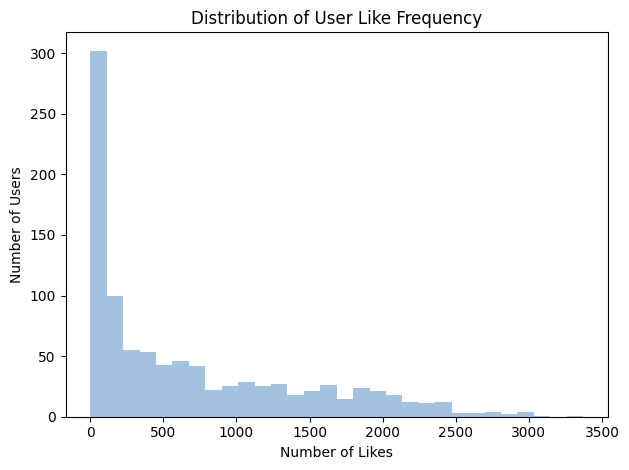

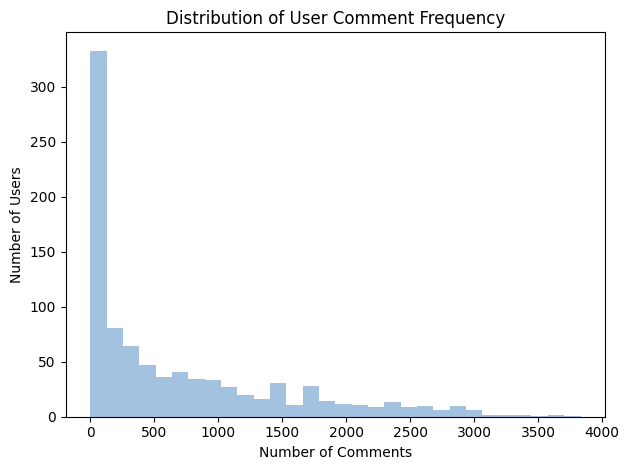

In [8]:
# Code here
# Like counts by user
user_like_counts = person_likes_post['Person.id'].value_counts().tolist()

# Comment counts by user
user_comment_counts = comment_hasCreator_person['Person.id'].value_counts().tolist()

# Plot distribution of user like frequency
plt.hist(user_like_counts, bins=30, color='#A2C2E0')
plt.title('Distribution of User Like Frequency')
plt.xlabel('Number of Likes')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

# Plot distribution of user comment frequency
plt.hist(user_comment_counts, bins=30, color='#A2C2E0')
plt.title('Distribution of User Comment Frequency')
plt.xlabel('Number of Comments')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()


Both distributions are right skewed. Most users tend to like/comment on only a few posts, which results in a higher concentration of users in the lower bins of the histograms. It is less likely for a user to be very actively engaged, which explains the long tail of the distribution towards the higher values.

# Question - 5. What is the Pearson correlation coefficient between the number of comments and the number of likes that users do on the social network? (4 points)

Print out one number. 



**Tip:** You can calculate correlation coefficient using the following formula: 
Assume that x and y are two arrays of data, in this case number of likes and comments of each user. n is the number of users. 

**Bonus Tip:** Consider that some users might have liked posts, but not liked any comments, or vice versa.

You can use whichever technique you would like for the question, as long as it has been discussed in lecture.

 


\begin{align*}
r= {{ n(\sum x y ) - (\sum x ) (\sum y)    } \over { \sqrt{ [ n \sum x^2  -
(\sum x)^2 ] [ n\sum y^2 - (\sum y )^2 ] } } }
\end{align*}











In [9]:
# Code here
# n = number of users
# x = user_like_counts
# y = user_comment_counts
# r = correlation coeff.

# like and comment frequency by user, taken from Q4
user_like_counts = person_likes_post['Person.id'].value_counts()
user_comment_counts = comment_hasCreator_person['Person.id'].value_counts()

# must make like and comment array the same size -> combine into new DataFrame, make NaN -> 0
user_activity = pd.concat([user_like_counts, user_comment_counts], axis=1)
user_activity.columns = ['likes', 'comments']
user_activity = user_activity.fillna(0)

# Create arrays for types of user activity
user_likes = np.array(user_activity['likes'])
user_comments = np.array(user_activity['comments'])

# Calculate correlation coefficient, r
r = user_activity.corr().loc['likes', 'comments']
print(f'The Pearson correlation coefficient between the number of likes and the number of comments per user is {r}.')
print('This means there is a strong positive correlation. Note: correlation ≠ causation!')

The Pearson correlation coefficient between the number of likes and the number of comments per user is 0.9243697363133554.
This means there is a strong positive correlation. Note: correlation ≠ causation!


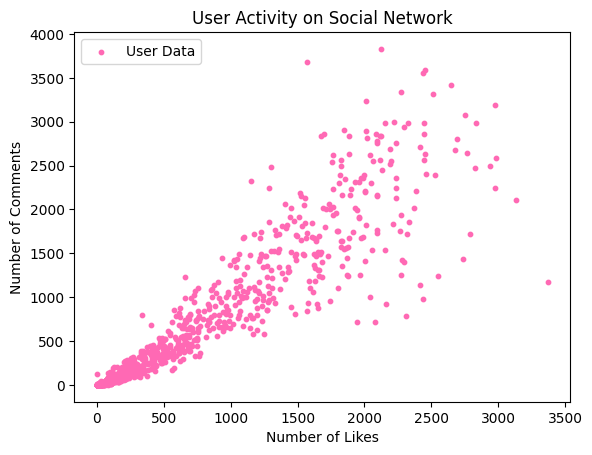

In [10]:
# Make scatterplot
plt.scatter(user_likes, user_comments, s=10, color='#FF69B4',label='User Data')
plt.title('User Activity on Social Network')
plt.xlabel('Number of Likes')
plt.ylabel('Number of Comments')
plt.legend(loc='upper left')
plt.show()